<a href="https://colab.research.google.com/github/keerthanasenthilvel3/HR-employee/blob/main/nm_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()
print("✅ File uploaded:", list(uploaded.keys()))

Saving Employee 1000x.csv to Employee 1000x.csv
✅ File uploaded: ['Employee 1000x.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported!")

✅ All libraries imported!


In [5]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Employee 1000x.csv']))
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor


In [6]:
df.columns = df.columns.str.strip()
df['Date of birth'] = pd.to_datetime(df['Date of birth'], dayfirst=True, errors='coerce')

today = pd.Timestamp.today()
df['Age'] = ((today - df['Date of birth']).dt.days // 365)
df.loc[df['Age'] < 18, 'Age'] = np.nan
df.loc[df['Age'] > 80, 'Age'] = np.nan

df.drop_duplicates(inplace=True)
df['Sex'] = df['Sex'].str.strip().str.capitalize()
df['Job Title'] = df['Job Title'].str.strip()

print("Missing values:\n", df.isnull().sum())
df[['First Name', 'Sex', 'Age', 'Job Title']].head(10)

Missing values:
 Index               0
First Name          0
Last Name           0
Sex                 0
Email               0
Phone               0
Date of birth       0
Job Title           0
Age              6975
dtype: int64


,First Name,Sex,Age,Job Title
0,Sara,Female,NaN,"Editor, commissioning"
1,Alisha,Male,NaN,Broadcast engineer
2,Gwendolyn,Male,NaN,Industrial buyer
3,Kristine,Female,47.0,Multimedia specialist
4,Bobby,Female,36.0,Planning and development surveyor
5,Calvin,Female,NaN,Therapeutic radiographer
6,Collin,Male,46.0,Administrator
7,Nicholas,Male,20.0,Fisheries officer
8,Emma,Female,NaN,Haematologist
9,Pedro,Male,18.0,Phytotherapist


In [7]:
print(f"Total Employees  : {len(df)}")
print(f"Unique Job Titles: {df['Job Title'].nunique()}")
print(f"Gender Breakdown : {df['Sex'].value_counts().to_dict()}")
print(f"Average Age      : {df['Age'].mean():.1f} years")
print(f"Age Range        : {int(df['Age'].min())} – {int(df['Age'].max())} years")

Total Employees  : 10000
Unique Job Titles: 639
Gender Breakdown : {'Female': 5074, 'Male': 4926}
Average Age      : 32.5 years
Age Range        : 18 – 50 years


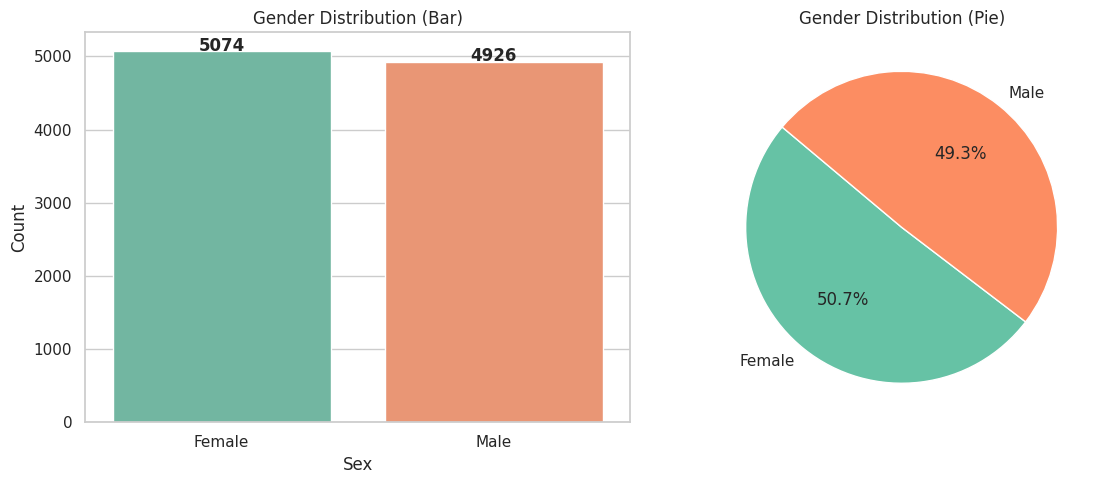

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_counts = df['Sex'].value_counts()

sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Gender Distribution (Bar)')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(gender_counts)))
axes[1].set_title('Gender Distribution (Pie)')

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=150)
plt.show()

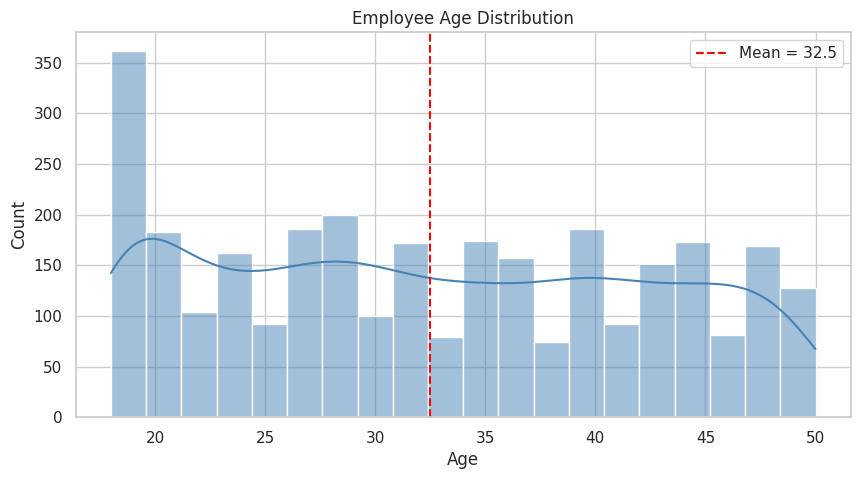

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), bins=20, kde=True, color='steelblue', edgecolor='white')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean = {df['Age'].mean():.1f}")
plt.title('Employee Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.savefig('age_distribution.png', dpi=150)
plt.show()

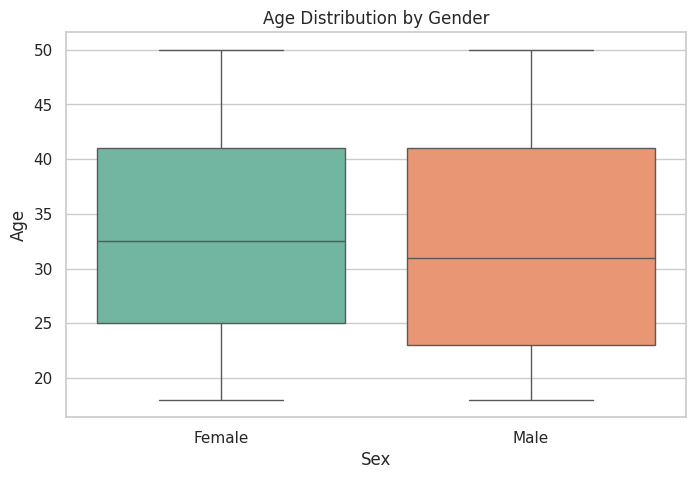

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sex', y='Age', data=df.dropna(subset=['Age']), palette='Set2')
plt.title('Age Distribution by Gender')
plt.savefig('age_by_gender.png', dpi=150)
plt.show()

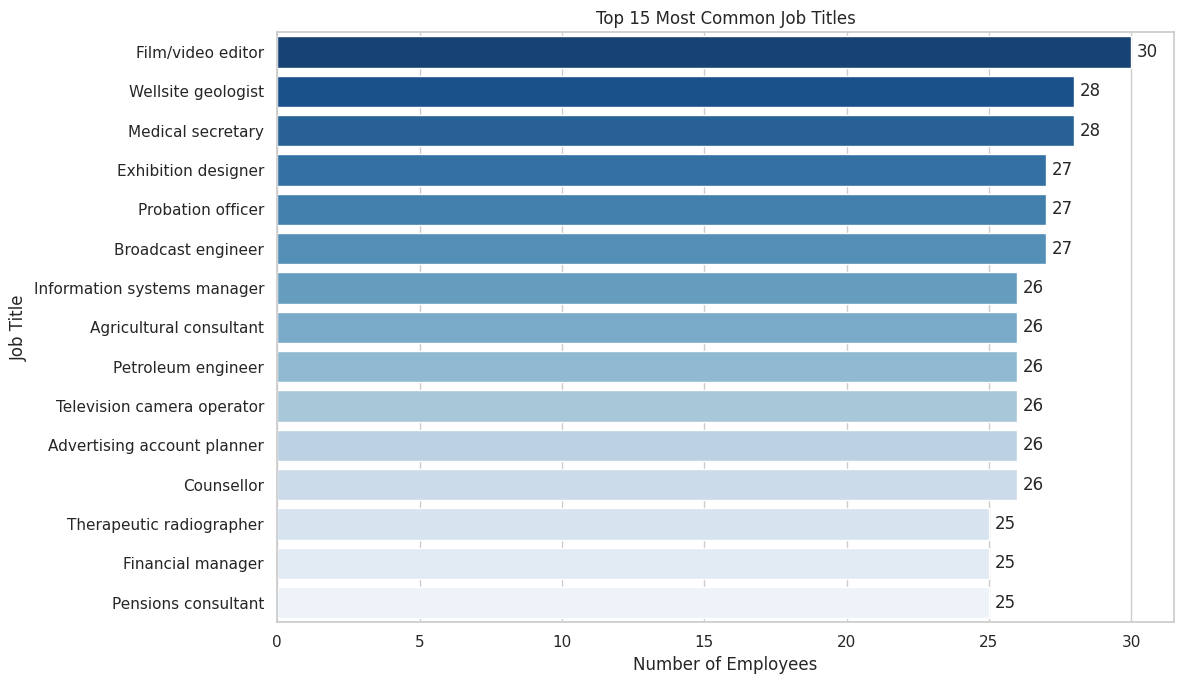

In [11]:
top_jobs = df['Job Title'].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='Blues_r')
plt.title('Top 15 Most Common Job Titles')
plt.xlabel('Number of Employees')
for i, v in enumerate(top_jobs.values):
    plt.text(v + 0.2, i, str(v), va='center')
plt.tight_layout()
plt.savefig('top_job_titles.png', dpi=150)
plt.show()

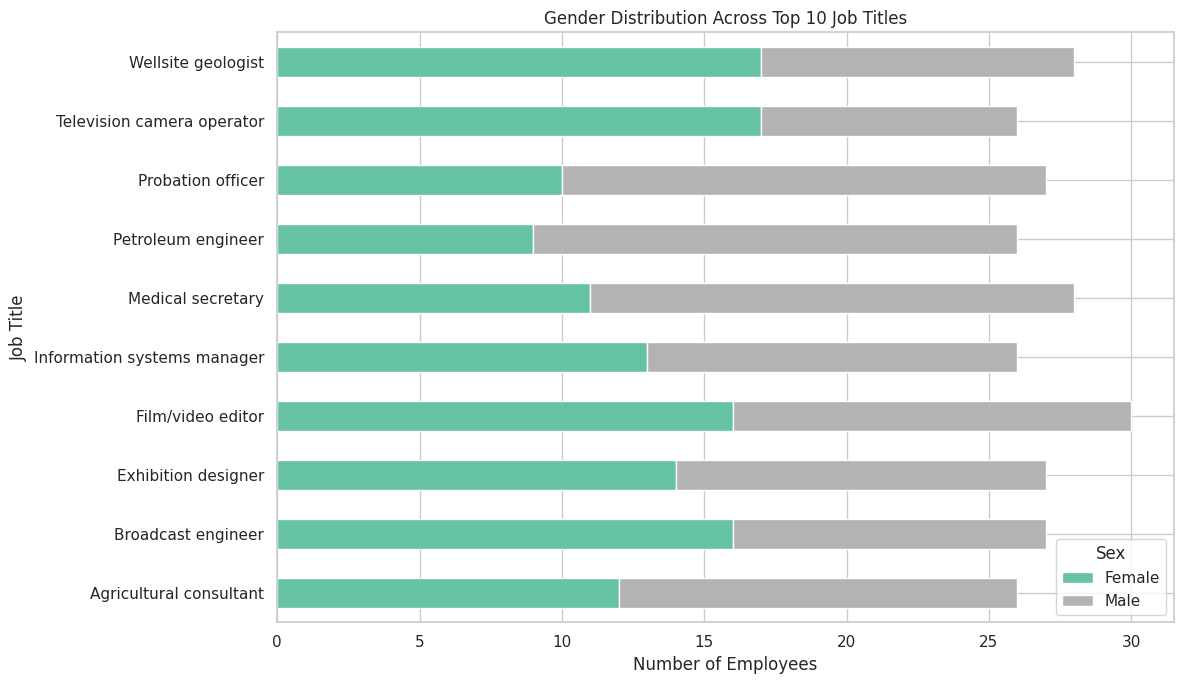

In [12]:
top10_jobs = df['Job Title'].value_counts().head(10).index.tolist()
df_top10 = df[df['Job Title'].isin(top10_jobs)]
gender_job = df_top10.groupby(['Job Title', 'Sex']).size().unstack(fill_value=0)

gender_job.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='Set2', edgecolor='white')
plt.title('Gender Distribution Across Top 10 Job Titles')
plt.xlabel('Number of Employees')
plt.tight_layout()
plt.savefig('gender_per_job.png', dpi=150)
plt.show()

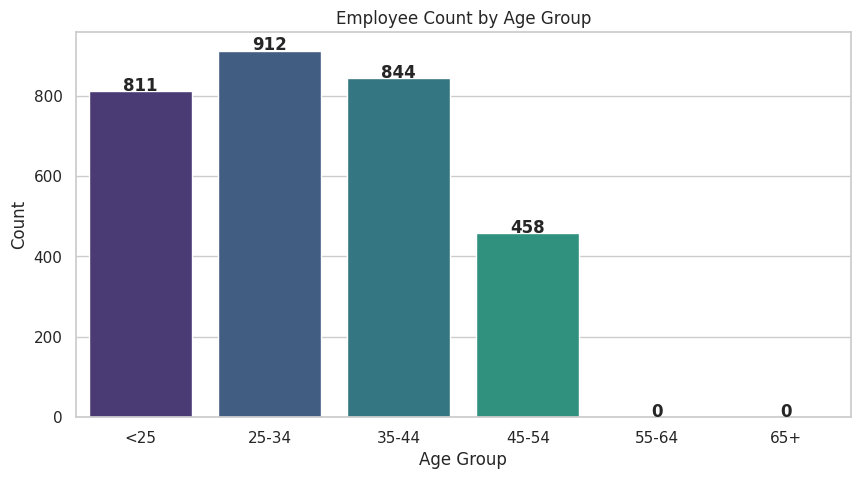

In [13]:
bins   = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_group_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=age_group_counts.index.astype(str), y=age_group_counts.values, palette='viridis')
plt.title('Employee Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
for i, v in enumerate(age_group_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.savefig('age_groups.png', dpi=150)
plt.show()

In [2]:
print('DataFrame Information:')
df.info()

DataFrame Information:


NameError: name 'df' is not defined

In [3]:
print('\nDescriptive Statistics:')
df.describe()


Descriptive Statistics:


NameError: name 'df' is not defined

In [4]:
heatmap_data = df.groupby(['Age Group', 'Sex']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Employee Count by Age Group & Gender')
plt.tight_layout()
plt.savefig('heatmap_age_gender.png', dpi=150)
plt.show()

NameError: name 'df' is not defined

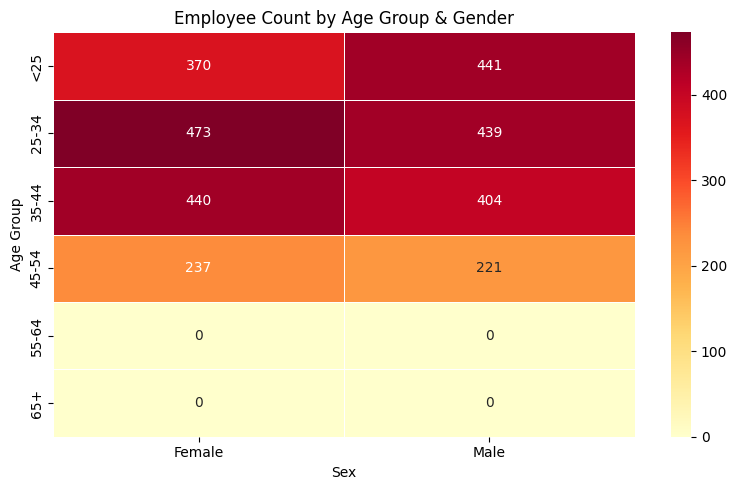

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Re-load df from uploaded files
df = pd.read_csv(io.BytesIO(uploaded['Employee 1000x.csv']))

# Re-apply data cleaning and feature engineering
df.columns = df.columns.str.strip()
df['Date of birth'] = pd.to_datetime(df['Date of birth'], dayfirst=True, errors='coerce')

today = pd.Timestamp.today()
df['Age'] = ((today - df['Date of birth']).dt.days // 365)
df.loc[df['Age'] < 18, 'Age'] = np.nan
df.loc[df['Age'] > 80, 'Age'] = np.nan

df.drop_duplicates(inplace=True)
df['Sex'] = df['Sex'].str.strip().str.capitalize()
df['Job Title'] = df['Job Title'].str.strip()

# Re-create 'Age Group' column
bins   = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Generate the heatmap
heatmap_data = df.groupby(['Age Group', 'Sex']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Employee Count by Age Group & Gender')
plt.tight_layout()
plt.savefig('heatmap_age_gender.png', dpi=150)
plt.show()

In [6]:
# Fix: reset index and convert Age Group to string first
df['Age Group'] = df['Age Group'].astype(str)

heatmap_data = df.groupby(['Age Group', 'Sex']).size().unstack(fill_value=0)

# Sort rows in correct age order
age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '65+', 'nan']
heatmap_data = heatmap_data.reindex([a for a in age_order if a in heatmap_data.index])

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Employee Count by Age Group & Gender')
plt.tight_layout()
plt.savefig('heatmap_age_gender.png', dpi=150)
plt.show()

NameError: name 'df' is not defined

In [7]:
# Step 1: Age Group column create பண்ணு
bins   = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False).astype(str)

# Step 2: Heatmap
heatmap_data = df.groupby(['Age Group', 'Sex']).size().unstack(fill_value=0)

age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
heatmap_data = heatmap_data.reindex([a for a in age_order if a in heatmap_data.index])

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Employee Count by Age Group & Gender')
plt.tight_layout()
plt.savefig('heatmap_age_gender.png', dpi=150)
plt.show()

NameError: name 'df' is not defined

✅ df ready! Shape: (10000, 10)


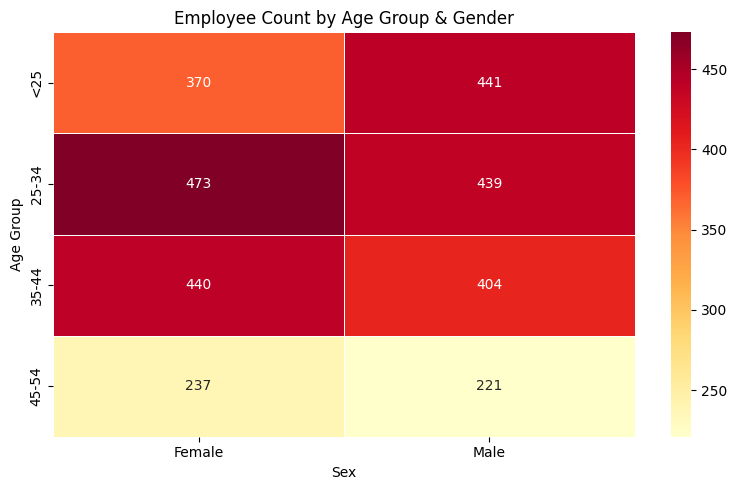

In [10]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import io
warnings.filterwarnings('ignore')

# Upload CSV (this step assumes the file 'Employee 1000x.csv' has been uploaded via files.upload() in a preceding cell)
# If running this cell independently, ensure files.upload() is run first, or upload the file using the UI.

# Load using io.BytesIO for robustness with uploaded files
df = pd.read_csv(io.BytesIO(uploaded['Employee 1000x.csv']))

# Clean
df.columns = df.columns.str.strip()
df['Date of birth'] = pd.to_datetime(df['Date of birth'], dayfirst=True, errors='coerce')
today = pd.Timestamp.today()
df['Age'] = ((today - df['Date of birth']).dt.days // 365)
df.loc[df['Age'] < 18, 'Age'] = np.nan
df.loc[df['Age'] > 80, 'Age'] = np.nan
df.drop_duplicates(inplace=True)
df['Sex'] = df['Sex'].str.strip().str.capitalize()
df['Job Title'] = df['Job Title'].str.strip()

# Age Group
bins   = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False).astype(str)

print("✅ df ready! Shape:", df.shape)

# Heatmap
heatmap_data = df.groupby(['Age Group', 'Sex']).size().unstack(fill_value=0)
age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
heatmap_data = heatmap_data.reindex([a for a in age_order if a in heatmap_data.index])

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Employee Count by Age Group & Gender')
plt.tight_layout()
plt.savefig('heatmap_age_gender.png', dpi=150)
plt.show()

In [11]:
top_job = df['Job Title'].value_counts().idxmax()
top_job_cnt = df['Job Title'].value_counts().max()
dominant_age = df['Age Group'].value_counts().idxmax()

print("=" * 50)
print("        📌 KEY INSIGHTS")
print("=" * 50)
print(f"  Total Employees       : {len(df)}")
print(f"  Male Employees        : {df[df['Sex']=='Male'].shape[0]}")
print(f"  Female Employees      : {df[df['Sex']=='Female'].shape[0]}")
print(f"  Average Age           : {df['Age'].mean():.1f} years")
print(f"  Largest Age Group     : {dominant_age}")
print(f"  Most Common Job Title : {top_job} ({top_job_cnt})")
print(f"  Unique Job Titles     : {df['Job Title'].nunique()}")
print("=" * 50)

        📌 KEY INSIGHTS
  Total Employees       : 10000
  Male Employees        : 4926
  Female Employees      : 5074
  Average Age           : 32.5 years
  Largest Age Group     : nan
  Most Common Job Title : Film/video editor (30)
  Unique Job Titles     : 639


In [13]:
df.to_csv('Employee_Cleaned.csv', index=False)
files.download('Employee_Cleaned.csv')
print("✅ Cleaned dataset downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Cleaned dataset downloaded!
